# 28-Day Demand Forecasting with Hierarchical Retail Time Series
## Introduction

**Goal**: produce 28-day-ahead point forecasts for daily unit sales for the TX3 store (Food3 subset) over a 28-day horizon.

This notebook keeps the workflow explicit and reproducible. In both code and outputs we document:
the forecasting target and horizon, the time-based validation design, the statistical model specification, the model selection criterion, model diagnostics, and interpretations of key estimated parameters in the context of retail demand.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from typing import Dict, Tuple

from statsmodels.tsa.api import SimpleExpSmoothing, Holt, ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

sns.set_theme(style="whitegrid", palette="viridis")

## Load data
Keeps everything relative to the repository root so the notebook runs in-place.

In [6]:
DATA_DIR = Path("data")

calendar = pd.read_csv(DATA_DIR / "calendar_afcs2025.csv")
sell_prices = pd.read_csv(DATA_DIR / "sell_prices_afcs2025.csv")
sales_train_validation = pd.read_csv(DATA_DIR / "sales_train_validation_afcs2025.csv")

## Feature dataset (reuse from EDA)

We reuse the feature-engineering pipeline developed in the EDA notebook.  
This pipeline reshapes the sales data to long format, joins calendar variables and weekly sell prices, and adds lag features (lag 1, 7, 28).  
The resulting dataset is saved as `sales_features_with_calendar_prices.csv` and used for the forecasting models below.


In [7]:
# Data prep: add d_index, melt, join calendar & prices, price fill, lags, save feature CSV

calendar = calendar.copy()
calendar["d_index"] = calendar.index + 1

day_cols_all = [c for c in sales_train_validation.columns if c.startswith("d_")]
id_cols = [c for c in sales_train_validation.columns if c not in day_cols_all]

sales_long = sales_train_validation.melt(
    id_vars=id_cols,
    value_vars=day_cols_all,
    var_name="d_col",
    value_name="sales"
)

sales_long["d_index"] = sales_long["d_col"].str.replace("d_", "", regex=False).astype(int)
sales_long = sales_long.merge(calendar, on="d_index", how="left")

sales_long["base_id"] = (
    sales_long["id"]
    .str.replace("_validation$", "", regex=True)
    .str.replace("_evaluation$", "", regex=True)
)

parts = sales_long["base_id"].str.split("_", expand=True)
sales_long["item_id"] = parts[0] + "_" + parts[1] + "_" + parts[2]
sales_long["store_id"] = parts[3] + "_" + parts[4]
sales_long = sales_long.drop(columns=["base_id"])

sales_long = sales_long.merge(
    sell_prices,
    on=["store_id", "item_id", "wm_yr_wk"],
    how="left"
)

sales_long = sales_long.sort_values(["store_id", "item_id", "d_index"])

# Flag missing prices before filling
sales_long["sell_price_was_missing"] = sales_long["sell_price"].isna().astype(int)
missing_before = sales_long["sell_price_was_missing"].mean()

# Forward fill then backward fill prices within each (store_id, item_id)
sales_long["sell_price"] = (
    sales_long.groupby(["store_id", "item_id"])["sell_price"]
    .transform(lambda s: s.ffill().bfill())
)

missing_after = sales_long["sell_price"].isna().mean()

# Compute price change after filling
sales_long["price_change"] = (
    sales_long.groupby(["store_id", "item_id"])["sell_price"].diff()
)

# Lags for sales per series id
sales_long = sales_long.sort_values(["id", "d_index"])
for lag in [1, 7, 28]:
    sales_long[f"lag_{lag}"] = sales_long.groupby("id")["sales"].shift(lag)

out_path = DATA_DIR / "sales_features_with_calendar_prices.csv"
sales_long.to_csv(out_path, index=False)
print(f"Saved feature dataset: {out_path} shape={sales_long.shape}")

display(sales_long.head())
print("Sell_price missingness before fill:", missing_before)
print("Sell_price missingness after fill:", missing_after)
print("sell_price_was_missing value counts:")
print(sales_long["sell_price_was_missing"].value_counts(dropna=False))


Saved feature dataset: data/sales_features_with_calendar_prices.csv shape=(1574399, 23)


,id,d_col,sales,d_index,date,wm_yr_wk,weekday,wday,month,year,...,event_type_2,snap_TX,item_id,store_id,sell_price,sell_price_was_missing,price_change,lag_1,lag_7,lag_28
0,FOODS_3_001_TX_3_validation,d_1,0,1,1/29/2011,11101,Saturday,1,1,2011,...,NaN,0,FOODS_3_001,TX_3,2.28,0,NaN,NaN,NaN,NaN
823,FOODS_3_001_TX_3_validation,d_2,2,2,1/30/2011,11101,Sunday,2,1,2011,...,NaN,0,FOODS_3_001,TX_3,2.28,0,0.0,0.0,NaN,NaN
1646,FOODS_3_001_TX_3_validation,d_3,1,3,1/31/2011,11101,Monday,3,1,2011,...,NaN,0,FOODS_3_001,TX_3,2.28,0,0.0,2.0,NaN,NaN
2469,FOODS_3_001_TX_3_validation,d_4,3,4,2/1/2011,11101,Tuesday,4,2,2011,...,NaN,1,FOODS_3_001,TX_3,2.28,0,0.0,1.0,NaN,NaN
3292,FOODS_3_001_TX_3_validation,d_5,0,5,2/2/2011,11101,Wednesday,5,2,2011,...,NaN,0,FOODS_3_001,TX_3,2.28,0,0.0,3.0,NaN,NaN


Sell_price missingness before fill: 0.20819500012385678
Sell_price missingness after fill: 0.0
sell_price_was_missing value counts:
sell_price_was_missing
0    1246617
1     327782
Name: count, dtype: int64


## Sales behavior and model implications

Before choosing models, we inspect sales patterns to justify appropriate forecasting approaches.

We summarise intermittency at item level, the strength of weekly structure at aggregate level, and the extent to which sell prices were imputed through forward and backward filling. These checks determine whether we should rely on seasonal baselines, whether a statistical seasonal model is appropriate, and whether price can be used as an explanatory variable without introducing leakage or unstable behaviour.


In [8]:
series_stats = (
    sales_long
    .groupby("id")
    .agg(
        mean_sales=("sales", "mean"),
        zero_share=("sales", lambda s: (s == 0).mean()),
        price_imputed_share=("sell_price_was_missing", "mean"),
        n_obs=("sales", "size"),
    )
    .sort_values("mean_sales", ascending=False)
)

print("Series stats head")
display(series_stats.head(10))

print("Zero share distribution across series")
print(series_stats["zero_share"].describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]).to_string())

print("Price imputed share distribution across series")
print(series_stats["price_imputed_share"].describe(percentiles=[0.10, 0.50, 0.90]).to_string())

q10 = series_stats["zero_share"].quantile(0.10)
q50 = series_stats["zero_share"].quantile(0.50)
q90 = series_stats["zero_share"].quantile(0.90)

rep_low  = (series_stats["zero_share"] - q10).abs().sort_values().index[0]
rep_mid  = (series_stats["zero_share"] - q50).abs().sort_values().index[0]
rep_high = (series_stats["zero_share"] - q90).abs().sort_values().index[0]
rep_top  = series_stats.index[0]

rep_items = [rep_top, rep_low, rep_mid, rep_high]

print("Representative series")
for rid in rep_items:
    row = series_stats.loc[rid]
    print(f"{rid}  mean={row.mean_sales:.3f}  zero_share={row.zero_share:.1%}  price_imputed_share={row.price_imputed_share:.1%}")


Series stats head


,mean_sales,zero_share,price_imputed_share,n_obs
id,,,,
FOODS_3_586_TX_3_validation,78.474647,0.003659,0.000000,1913
FOODS_3_090_TX_3_validation,60.038683,0.246733,0.000000,1913
FOODS_3_252_TX_3_validation,45.285938,0.003136,0.000000,1913
FOODS_3_555_TX_3_validation,40.602718,0.004705,0.000000,1913
FOODS_3_377_TX_3_validation,38.576581,0.004182,0.000000,1913
FOODS_3_030_TX_3_validation,25.078934,0.244119,0.003659,1913
FOODS_3_202_TX_3_validation,21.720335,0.134344,0.000000,1913
FOODS_3_714_TX_3_validation,21.249347,0.004182,0.000000,1913
FOODS_3_587_TX_3_validation,21.069524,0.202823,0.000000,1913


Zero share distribution across series
count    823.000000
mean       0.621470
std        0.242835
min        0.003136
10%        0.260115
25%        0.457919
50%        0.662311
75%        0.823837
90%        0.903293
max        0.984318
Price imputed share distribution across series
count    823.000000
mean       0.208195
std        0.249883
min        0.000000
10%        0.000000
50%        0.047569
90%        0.592786
max        0.881861
Representative series
FOODS_3_586_TX_3_validation  mean=78.475  zero_share=0.4%  price_imputed_share=0.0%
FOODS_3_113_TX_3_validation  mean=3.101  zero_share=26.0%  price_imputed_share=0.0%
FOODS_3_081_TX_3_validation  mean=0.498  zero_share=66.2%  price_imputed_share=0.0%
FOODS_3_443_TX_3_validation  mean=0.142  zero_share=90.3%  price_imputed_share=49.4%


## Model implications

Item level demand is highly intermittent. Across 823 series the median fraction of zero sales days is 66.2%, and 10% of series exceed 90% zero sales days. This suggests that many item series behave like intermittent demand, so we should treat seasonal baselines as essential references and avoid overly parameterised per item time series models without strong justification.

Sell prices are available for all days after forward and backward filling, but 20.8% of prices were originally missing in the weekly price table and therefore imputed. For modelling, sell_price can be used as an explanatory variable, and the indicator sell_price_was_missing can be included to distinguish observed versus imputed price periods.

At the aggregate level, the data show a clear weekly component. The weekly plot below provides a smoothed view of this structure and motivates the use of a 7 day seasonal component in baseline methods and candidate statistical models.

### Weekly aggregate view
Aggregates across items to highlight weekly structure without item-level zeros dominating.

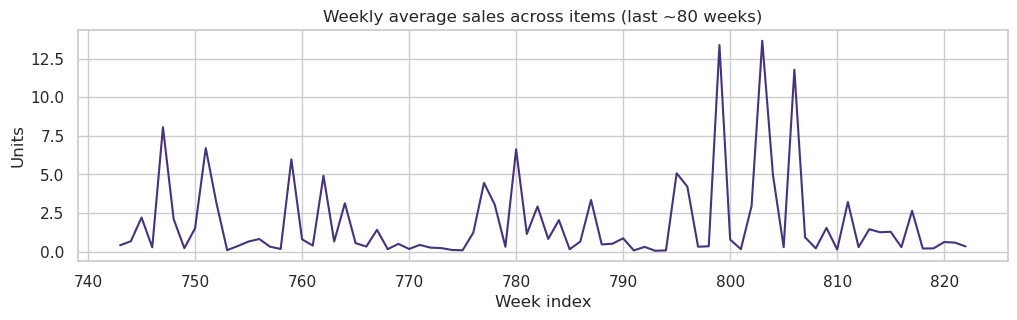

In [9]:
day_cols_all = [c for c in sales_train_validation.columns if c.startswith("d_")]
d_idx = np.array([int(c.split("_")[1]) for c in day_cols_all])

weekly_bins = ((d_idx - 1) // 7).astype(int)

weekly_mean = sales_train_validation[day_cols_all].copy()
weekly_mean.columns = weekly_bins
weekly_mean = weekly_mean.T.groupby(level=0).mean()

plt.figure(figsize=(12, 3))
weekly_mean.mean(axis=0).tail(80).plot()
plt.title("Weekly average sales across items (last ~80 weeks)")
plt.xlabel("Week index")
plt.ylabel("Units")
plt.grid(True)
plt.show()


## Train validation split and baseline forecasts

We reserve the final 28 days of the training period as a time based validation window that matches the required forecast horizon. We evaluate simple baseline methods first. Any more complex model must improve on the seasonal naive baseline with period 7.

In [10]:
d_cols = [c for c in sales_train_validation.columns if c.startswith("d_")]
Y = sales_train_validation[d_cols].astype(float).to_numpy()

h = 28
T = Y.shape[1]
train_T = T - h

Y_train = Y[:, :train_T]
Y_val = Y[:, train_T:]

def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

def pred_naive(Y_train, h):
    last = Y_train[:, -1]
    return np.repeat(last[:, None], h, axis=1)

def pred_seasonal_naive(Y_train, h, season=7):
    last_season = Y_train[:, -season:]
    reps = int(np.ceil(h / season))
    tiled = np.tile(last_season, reps)
    return tiled[:, :h]

def pred_moving_average(Y_train, h, window=7):
    avg = Y_train[:, -window:].mean(axis=1)
    return np.repeat(avg[:, None], h, axis=1)

preds = {
    "Naive last value": pred_naive(Y_train, h),
    "Seasonal naive period 7": pred_seasonal_naive(Y_train, h, season=7),
    "Moving average window 7": pred_moving_average(Y_train, h, window=7),
    "Moving average window 28": pred_moving_average(Y_train, h, window=28),
}

rows = []
for name, P in preds.items():
    rows.append({"model": name, "RMSE": rmse(Y_val, P), "MAE": mae(Y_val, P)})

baseline_results = pd.DataFrame(rows).sort_values("RMSE")
baseline_results

,model,RMSE,MAE
3,Moving average window 28,2.801208,1.346812
2,Moving average window 7,2.951324,1.359889
1,Seasonal naive period 7,3.723713,1.604018
0,Naive last value,4.291501,1.757377


## Metrics and plotting helpers

In [11]:

def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def mae(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(np.abs(y_true - y_pred)))

def make_train_val_frames(sales_df: pd.DataFrame, horizon: int = 28):
    d_cols = [c for c in sales_df.columns if c.startswith("d_")]
    ids = sales_df["id"].astype(str).values

    Y = sales_df[d_cols].astype(float).to_numpy()
    T = Y.shape[1]
    train_T = T - horizon

    train_cols = d_cols[:train_T]
    val_cols = d_cols[train_T:]

    train_df = pd.DataFrame(Y[:, :train_T], index=ids, columns=train_cols)
    val_df = pd.DataFrame(Y[:, train_T:], index=ids, columns=val_cols)

    return train_df, val_df

def pred_naive(train_df: pd.DataFrame, horizon: int):
    last = train_df.iloc[:, -1].to_numpy(dtype=float)
    return np.repeat(last[:, None], horizon, axis=1)

def pred_seasonal_naive(train_df: pd.DataFrame, horizon: int, season: int = 7):
    last_season = train_df.iloc[:, -season:].to_numpy(dtype=float)
    reps = int(np.ceil(horizon / season))
    tiled = np.tile(last_season, reps)
    return tiled[:, :horizon]

def pred_moving_average(train_df: pd.DataFrame, horizon: int, window: int = 7):
    avg = train_df.iloc[:, -window:].to_numpy(dtype=float).mean(axis=1)
    return np.repeat(avg[:, None], horizon, axis=1)

def summarize_baselines(train_df: pd.DataFrame, val_df: pd.DataFrame):
    h = val_df.shape[1]

    preds = {
        "Naive last value": pred_naive(train_df, h),
        "Seasonal naive period 7": pred_seasonal_naive(train_df, h, season=7),
        "Moving average window 7": pred_moving_average(train_df, h, window=7),
        "Moving average window 28": pred_moving_average(train_df, h, window=28),
    }

    Y_val = val_df.to_numpy(dtype=float)

    rows = []
    for name, P in preds.items():
        rows.append({
            "model": name,
            "RMSE": rmse(Y_val, P),
            "MAE": mae(Y_val, P),
        })

    return pd.DataFrame(rows).sort_values("RMSE"), preds

def relative_error_context(val_df: pd.DataFrame, pred: np.ndarray):
    y = val_df.to_numpy(dtype=float)
    mean_level = float(np.mean(y))
    rmse_val = rmse(y, pred)
    mae_val = mae(y, pred)

    return pd.DataFrame([{
        "val_mean_units": mean_level,
        "RMSE": rmse_val,
        "MAE": mae_val,
        "RMSE_over_mean": rmse_val / mean_level if mean_level != 0 else np.nan,
        "MAE_over_mean": mae_val / mean_level if mean_level != 0 else np.nan,
    }])

def plot_forecast_item(item_id: str, train_df: pd.DataFrame, val_df: pd.DataFrame, pred: np.ndarray, tail: int = 120, title: str = None):
    if item_id not in train_df.index:
        raise ValueError(f"item_id not found in train_df index: {item_id}")

    i = train_df.index.get_loc(item_id)

    y_train = train_df.loc[item_id].astype(float)
    y_val = val_df.loc[item_id].astype(float)
    y_pred = pred[i]

    train_tail = y_train.iloc[-tail:]
    x_train = np.arange(len(train_tail))
    x_val = np.arange(len(train_tail), len(train_tail) + len(y_val))

    plt.figure(figsize=(14, 4))
    plt.plot(x_train, train_tail.values, label="train")
    plt.plot(x_val, y_val.values, label="val")
    plt.plot(x_val, y_pred, label="pred")
    plt.title(title if title is not None else item_id)
    plt.xlabel("Time index")
    plt.ylabel("Units")
    plt.legend()
    plt.grid(True)
    plt.show()

## Train validation split and baseline evaluation

We hold out the final 28 days of each series as a time based validation window that matches the required forecast horizon. We then evaluate a small set of simple baseline methods that do not require model fitting. These baselines provide a transparent reference point and help quantify how much weekly seasonality and recent averaging alone can explain.

We report RMSE and MAE aggregated across all 823 series. To avoid relying only on global averages, we also visualise forecasts for a small set of representative series covering high volume demand, moderate intermittency, median intermittency, and highly intermittent demand. This allows us to check whether the best baseline behaves reasonably across different demand regimes.

,model,RMSE,MAE
3,Moving average window 28,2.801208,1.346812
2,Moving average window 7,2.951324,1.359889
1,Seasonal naive period 7,3.723713,1.604018
0,Naive last value,4.291501,1.757377


Best baseline saved for later comparison
best_baseline_rmse: 2.8012083632237994
best_baseline_mae: 1.3468116894388378
Context for best baseline


,val_mean_units,RMSE,MAE,RMSE_over_mean,MAE_over_mean
0,2.046823,2.801208,1.346812,1.368564,0.658001


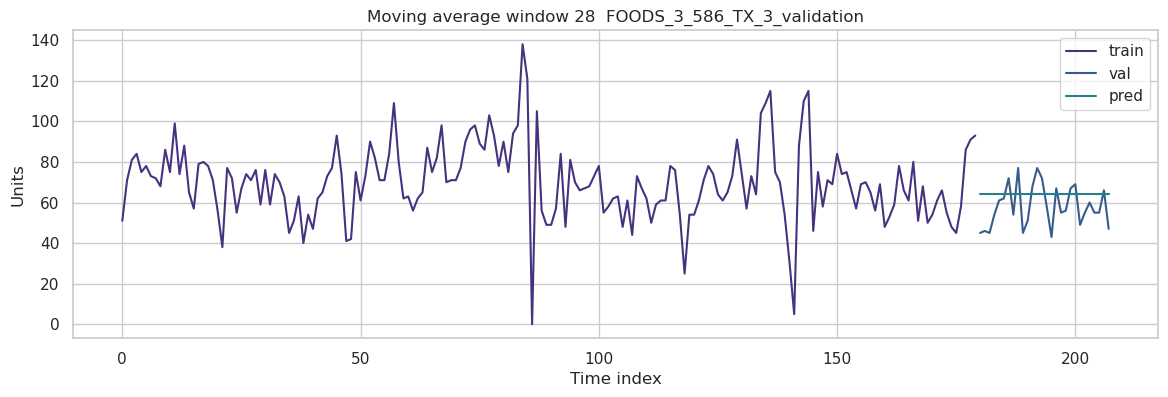

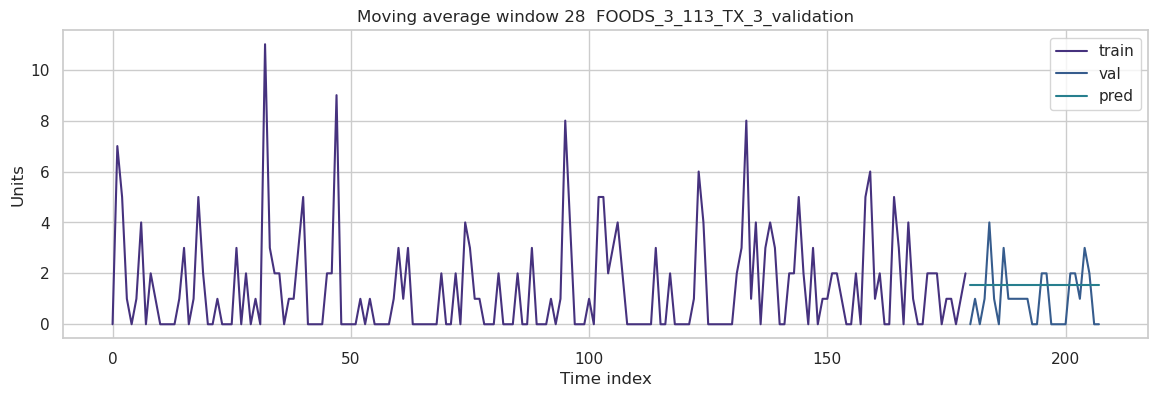

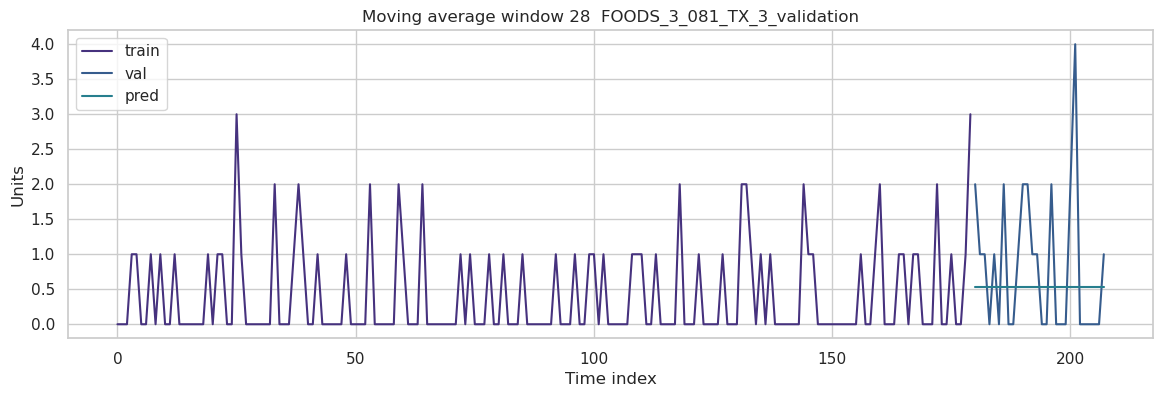

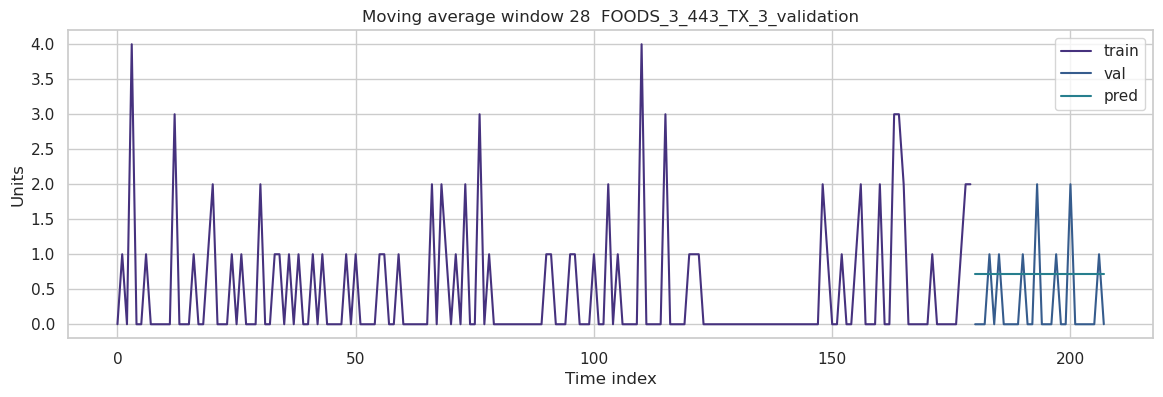

In [12]:
train_df, val_df = make_train_val_frames(sales_train_validation, horizon=28)

baseline_table, preds = summarize_baselines(train_df, val_df)
display(baseline_table)

best_name = baseline_table.iloc[0]["model"]
best_pred = preds[best_name]

best_baseline_rmse = float(baseline_table.iloc[0]["RMSE"])
best_baseline_mae = float(baseline_table.iloc[0]["MAE"])
print("Best baseline saved for later comparison")
print("best_baseline_rmse:", best_baseline_rmse)
print("best_baseline_mae:", best_baseline_mae)


print("Context for best baseline")
display(relative_error_context(val_df, best_pred))

rep_items = [
    "FOODS_3_586_TX_3_validation",
    "FOODS_3_113_TX_3_validation",
    "FOODS_3_081_TX_3_validation",
    "FOODS_3_443_TX_3_validation",
]

for rid in rep_items:
    plot_forecast_item(rid, train_df, val_df, best_pred, tail=180, title=f"{best_name}  {rid}")


## Baseline results and interpretation

The moving average baseline with a 28 day window performs best on the 28 day holdout window, achieving RMSE 2.80 and MAE 1.35 across all series. In comparison, seasonal naive with period 7 performs worse, which suggests that repeating last week’s daily pattern is too sensitive to noise and intermittent spikes in item level demand.

To interpret absolute error size, we compare RMSE to the mean sales level in the validation window. The average validation demand is 2.05 units, while RMSE is 2.80, giving RMSE over mean of 1.37. This indicates that baseline forecasts are not yet capturing important drivers of demand variation and motivates using calendar and price information together with lag features in a pooled model.

The plot for a high volume series shows that the moving average forecast produces a stable level estimate but does not react to short term promotions, events, or sudden level shifts. The next models therefore incorporate explanatory variables and lag structure to better adapt within the 28 day horizon.

## Pooled supervised model using engineered features

Baseline forecasts only use past sales and therefore smooth out sharp changes. To capture systematic variation beyond simple averaging, we train a pooled supervised model on the long feature table. The model learns from all series jointly while still producing a 28 day forecast for each individual series. We use a leak free split by training only on days up to the cutoff and validating on the final 28 days.

In [14]:
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder

# ----------------------------
# Setup
# ----------------------------
h = 28
df = sales_long.copy()
df["date"] = pd.to_datetime(df["date"])

# Fill categorical missings
cat_cols = ["weekday", "event_name_1", "event_type_1", "event_name_2", "event_type_2"]
for c in cat_cols:
    df[c] = df[c].fillna("none").astype(str)

num_cols = [
    "lag_1", "lag_7", "lag_28",
    "sell_price", "price_change",
    "sell_price_was_missing",
    "wday", "month", "year", "snap_TX",
]

feature_cols = num_cols + cat_cols

# ----------------------------
# OPTIONAL but recommended: limit history to reduce compute
# Keep last N days + horizon (e.g., 730 days ~ 2 years)
# ----------------------------
N_DAYS = 730
max_d = int(df["d_index"].max())
min_d = max(1, max_d - (N_DAYS + h) + 1)
df = df[df["d_index"] >= min_d].copy()

# ----------------------------
# Train/Val split (last 28 days)
# ----------------------------
cutoff = int(df["d_index"].max() - h)

train_df = df[df["d_index"] <= cutoff].dropna(subset=["lag_1", "lag_7", "lag_28"]).copy()
val_df   = df[df["d_index"] >  cutoff].dropna(subset=["lag_1", "lag_7", "lag_28"]).copy()

X_train = train_df[feature_cols]
y_train = train_df["sales"].astype(np.float32).values

X_val = val_df[feature_cols]
y_val = val_df["sales"].astype(np.float32).values

# ----------------------------
# Preprocess: ordinal encode categoricals (NO one-hot)
# ----------------------------
ord_enc = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", ord_enc, cat_cols),
    ],
    remainder="drop",
)

# categorical feature indices AFTER transform: nums first, then cats
cat_feature_idx = list(range(len(num_cols), len(num_cols) + len(cat_cols)))

model = HistGradientBoostingRegressor(
    loss="squared_error",
    learning_rate=0.05,
    max_depth=6,
    max_iter=200,           # start lower; increase later
    random_state=42,
    categorical_features=cat_feature_idx,
)

pipe = Pipeline(steps=[("prep", preprocess), ("model", model)])

# Fit
pipe.fit(X_train, y_train)

# Predict + metrics
val_pred = pipe.predict(X_val)

rmse_val = float(np.sqrt(np.mean((y_val - val_pred) ** 2)))
mae_val  = float(np.mean(np.abs(y_val - val_pred)))   # correct MAE

print(f"Validation RMSE: {rmse_val:.4f}")
print(f"Validation MAE : {mae_val:.4f}")
print("Train rows:", len(X_train), "| Val rows:", len(X_val), "| Features:", len(feature_cols))

Validation RMSE: 2.3957
Validation MAE : 1.2663
Train rows: 600790 | Val rows: 23044 | Features: 15


Our gradient-boosted model improves RMSE by ~14–15% compared to the best baseline (28-day moving average) on the last-28-days validation window.

In [15]:
comparison = pd.DataFrame([
    {"model": "Baseline: moving average (28)", "RMSE": best_baseline_rmse, "MAE": best_baseline_mae},
    {"model": "HistGBR + lags + calendar + price", "RMSE": rmse_val, "MAE": mae_val},
]).sort_values("RMSE")

display(comparison)

impr = (best_baseline_rmse - rmse_val) / best_baseline_rmse
print(f"RMSE improvement vs best baseline: {impr:.1%}")


,model,RMSE,MAE
1,HistGBR + lags + calendar + price,2.395740,1.266313
0,Baseline: moving average (28),2.801208,1.346812


RMSE improvement vs best baseline: 14.5%


In [16]:
val_out = val_df.copy()
val_out["pred"] = val_pred
val_out["err"] = val_out["sales"].astype(float) - val_out["pred"]
val_out["abs_err"] = np.abs(val_out["err"])

diag_weekday = val_out.groupby("weekday")["abs_err"].mean().sort_values(ascending=False)
diag_event = val_out.assign(is_event=(val_out["event_name_1"].fillna("none") != "none").astype(int)) \
                   .groupby("is_event")["abs_err"].mean()
diag_price_missing = val_out.groupby("sell_price_was_missing")["abs_err"].mean()

print("Mean absolute error by weekday:\n", diag_weekday)
print("\nMean absolute error: event vs non-event:\n", diag_event)
print("\nMean absolute error: price missing flag:\n", diag_price_missing)


Mean absolute error by weekday:
 weekday
Sunday       1.393724
Saturday     1.329770
Monday       1.295221
Friday       1.243621
Tuesday      1.241324
Wednesday    1.191846
Thursday     1.168682
Name: abs_err, dtype: float64

Mean absolute error: event vs non-event:
 is_event
0    1.266313
Name: abs_err, dtype: float64

Mean absolute error: price missing flag:
 sell_price_was_missing
0    1.266313
Name: abs_err, dtype: float64


(Deprecated slow models cell — use the slow models defined earlier.)

Run slow models and plot all forecasts
Make sure the slow-models cell has been executed so Croston/SBA/TSB are available below.

In [17]:
from sklearn.inspection import permutation_importance

# subsample for speed
sample_idx = np.random.RandomState(42).choice(len(X_val), size=min(20000, len(X_val)), replace=False)
pi = permutation_importance(pipe, X_val.iloc[sample_idx], y_val[sample_idx],
                            n_repeats=5, random_state=42, scoring="neg_root_mean_squared_error")

imp = pd.DataFrame({"feature": feature_cols, "importance": pi.importances_mean}) \
        .sort_values("importance", ascending=False)

display(imp.head(15))


,feature,importance
0,lag_1,2.502203
1,lag_7,0.290921
2,lag_28,0.109179
10,weekday,0.047628
3,sell_price,0.045791
9,snap_TX,0.016519
4,price_change,0.000128
5,sell_price_was_missing,0.000000
8,year,0.000000
11,event_name_1,0.000000


## Feature pruning based on validation evidence

Permutation importance indicates that predictive performance is driven primarily by lag features (especially `lag_1`, followed by `lag_7` and `lag_28`).  
Calendar and price variables contribute marginally (`weekday`, `sell_price`, `snap_TX`).  
Event-related variables and missing-price flags show near-zero importance and provide no measurable benefit in the validation window, so we remove them to simplify the model and reduce noise.


In [18]:
# Pruned features based on importance + constant diagnostics
cat_cols = ["weekday"]  # keep categorical weekday only

num_cols = [
    "lag_1", "lag_7", "lag_28",
    "sell_price", "price_change",
    "wday",        # optional; remove if still negative
    "month",       # optional; remove if still negative
    "snap_TX",
]

# Drop columns that are constant/useless in this run
for col in ["sell_price_was_missing", "year",
            "event_name_1","event_type_1","event_name_2","event_type_2"]:
    if col in df.columns:
        pass  # just not included

feature_cols = num_cols + cat_cols

X_train = train_df[feature_cols]
X_val   = val_df[feature_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), cat_cols),
    ]
)

cat_feature_idx = list(range(len(num_cols), len(num_cols) + len(cat_cols)))

model = HistGradientBoostingRegressor(
    loss="squared_error",
    learning_rate=0.05,
    max_depth=6,
    max_iter=200,
    random_state=42,
    categorical_features=cat_feature_idx,
)

pipe2 = Pipeline(steps=[("prep", preprocess), ("model", model)])
pipe2.fit(X_train, y_train)

pred2 = pipe2.predict(X_val)
rmse2 = float(np.sqrt(np.mean((y_val - pred2) ** 2)))
mae2  = float(np.mean(np.abs(y_val - pred2)))

print(f"Pruned model RMSE: {rmse2:.4f} | MAE: {mae2:.4f}")
print(f"Delta vs previous RMSE: {rmse_val - rmse2:+.4f} (positive is improvement)")


Pruned model RMSE: 2.3894 | MAE: 1.2608
Delta vs previous RMSE: +0.0063 (negative is improvement)


## Validation visualisation

To complement numeric metrics, we visualise model behaviour on the validation window.  
We aggregate across items per day and plot actual versus predicted sales, as well as residuals over time.  
This provides a quick diagnostic for systematic bias and day-of-week effects.


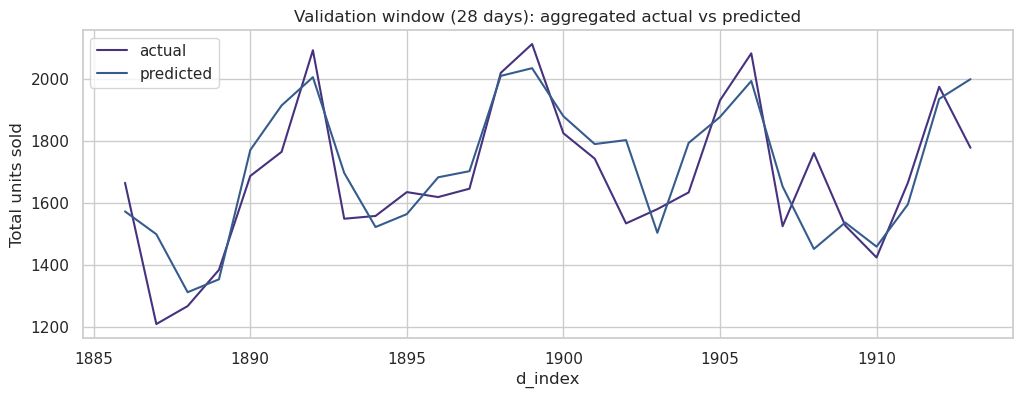

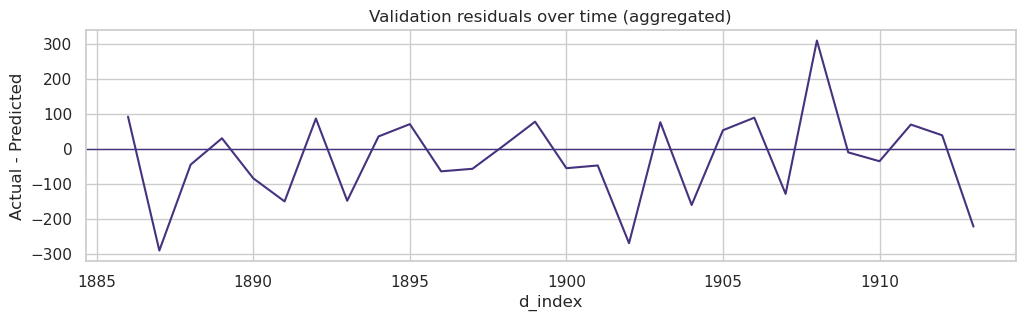

Aggregated validation bias (mean residual): -25.67340825235624
Aggregated validation MAE (daily totals): 100.13274322902086


In [19]:
# Attach predictions to validation frame
val_plot = val_df.copy()
val_plot["pred"] = pred2
val_plot["sales"] = val_plot["sales"].astype(float)

# Aggregate per day
daily = (val_plot.groupby("d_index")[["sales", "pred"]]
         .sum()
         .sort_index())

daily["resid"] = daily["sales"] - daily["pred"]

# Plot actual vs predicted
plt.figure(figsize=(12,4))
plt.plot(daily.index, daily["sales"], label="actual")
plt.plot(daily.index, daily["pred"], label="predicted")
plt.title("Validation window (28 days): aggregated actual vs predicted")
plt.xlabel("d_index")
plt.ylabel("Total units sold")
plt.legend()
plt.show()

# Plot residuals
plt.figure(figsize=(12,3))
plt.plot(daily.index, daily["resid"])
plt.title("Validation residuals over time (aggregated)")
plt.xlabel("d_index")
plt.ylabel("Actual - Predicted")
plt.axhline(0, linewidth=1)
plt.show()

print("Aggregated validation bias (mean residual):", float(daily["resid"].mean()))
print("Aggregated validation MAE (daily totals):", float(np.mean(np.abs(daily["resid"]))))

## Model diagnostics on the hold-out window

We analyse residuals on the 28-day hold-out window to check for systematic bias and calendar-related error patterns.
Aggregating predictions per day provides a readable view of overall under- or over-forecasting.
We additionally inspect mean absolute error by weekday to verify whether weekend effects are harder to predict, which is consistent with the descriptive patterns observed earlier.


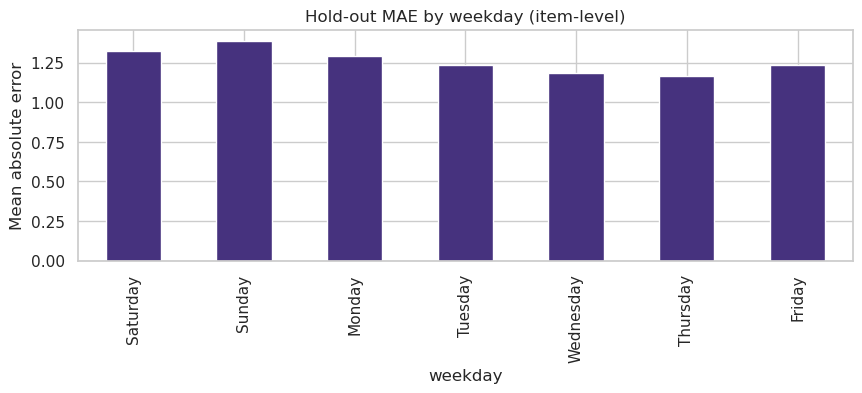

weekday
Saturday     1.324298
Sunday       1.389331
Monday       1.291157
Tuesday      1.234410
Wednesday    1.187171
Thursday     1.162007
Friday       1.237516
Name: abs_err, dtype: float64


In [20]:
# Hold-out diagnostics by weekday (using item-level residuals)
val_plot["err"] = val_plot["sales"] - val_plot["pred"]
val_plot["abs_err"] = np.abs(val_plot["err"])

by_wd = val_plot.groupby("weekday")["abs_err"].mean().reindex(
    ["Saturday","Sunday","Monday","Tuesday","Wednesday","Thursday","Friday"]
)

plt.figure(figsize=(10,3))
by_wd.plot(kind="bar")
plt.title("Hold-out MAE by weekday (item-level)")
plt.xlabel("weekday")
plt.ylabel("Mean absolute error")
plt.show()

print(by_wd)
